In [146]:
import numpy as np
import pandas as pd
import random
import json
from datasets import load_dataset, concatenate_datasets

random.seed(42)

In [148]:
train_combined_cs_df = pd.DataFrame(columns=["codeswitch_sentence", "languages", "dataset_source"])
test_combined_cs_df = pd.DataFrame(columns=["codeswitch_sentence", "languages", "dataset_source"])

In [149]:
train_combined_cs_df.head()

,codeswitch_sentence,languages,dataset_source


CSPref [English-Malayalam, Eng-Hindi, English-Tamil]

CSPref is a curated human preference dataset for evaluating the fluency and accuracy of code-switched text generation. Built specifically for multilingual NLP research, CSPREF is designed to help researchers and developers tune and evaluate models for code-switching tasks across diverse language pairs. The dataset provides valuable insights into human preferences, allowing for better alignment of language models with natural code-switching patterns and improving the quality of generated multilingual content.

https://huggingface.co/datasets/garrykuwanto/cspref

In [5]:
# REMOVING FOR NOW BECAUSE IT IS NOT CLEAN

# splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
# cspref_df = pd.read_parquet("hf://datasets/garrykuwanto/cspref/" + splits["train"])
# cspref_df.head()
# def resolve_choice(row):
#     if row['chosen'] == 'sent_1':
#         return row['sent_1']
#     elif row['chosen'] == 'sent_2':
#         return row['sent_2']

# cspref_df['codeswitch_sentence'] = cspref_df.apply(resolve_choice, axis=1)
# cspref_df['languages'] = cspref_df['lang']

# combined_cs_df['codeswitch_sentence'] = cspref_df['codeswitch_sentence']
# combined_cs_df['languages'] = cspref_df['languages']

# combined_cs_df.head()
# unique_sentences = combined_cs_df['codeswitch_sentence'].unique()
# unique_sentences
# combined_cs_df
# combined_cs_df = combined_cs_df.drop_duplicates(subset='codeswitch_sentence', keep='first')

# combined_cs_df
# cspref_subset = combined_cs_df

BaSCo Basque–Spanish dataset
https://github.com/Vicomtech/BaSCo-Corpus


In [150]:
with open('subdatasets/BaSCo/valid_utterances.json', 'r', encoding='utf-8') as f:
    basco_data = json.load(f)

In [152]:
cs_entries = []
for item in basco_data:
    for cs in item.get('code-switching', []):
        cs_entries.append({
            'codeswitch_sentence': cs['text'].strip(),
            'languages': 'Basque–Spanish',
            'dataset_source': "BaSCo"
        })

In [153]:
cs_basco_df = pd.DataFrame(cs_entries)

In [154]:
cs_basco_df = cs_basco_df.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [156]:
shuffled_cs_basco_df = cs_basco_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, shuffled_cs_basco_df[:int(0.7 * len(shuffled_cs_basco_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, shuffled_cs_basco_df[int(0.7 * len(shuffled_cs_basco_df)):]])

Dravidian-CodeMix

Tamil-English: 15744 comments, Train: 11,335 Validation: 1,260 and Test: 3,149

Malayalam-English: 6,739 comments, Train: 4,851 Validation: 541 and Test: 1,348

We present Tamil-English and Malayalam-English, a dataset of YouTube video comments. The dataset contains all the three types of code-mixed sentences -- Inter-Sentential switch, Intra-Sentential switch and Tag switching. Most comments were written in Roman script with either Tamil / Malayalam grammar with English lexicon or English grammar with Tamil / Malayalam lexicon. Some comments were written in Tamil / Malayalam script with English expressions in between.

https://dravidian-codemix.github.io/2020/datasets.html

In [158]:
malayalam_dev_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/train/malayalam_dev.tsv", sep='\t')
malayalam_train_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/train/malayalam_train.tsv", sep='\t')

In [159]:
malayalam_dev_df = malayalam_dev_df[malayalam_dev_df['category'] != 'not-malayalam']
malayalam_train_df = malayalam_train_df[malayalam_train_df['category'] != 'not-malayalam']

In [160]:
malayalam_train_subset = malayalam_train_df[['text']].copy()
malayalam_train_subset = malayalam_train_subset.rename(columns={'text': 'codeswitch_sentence'})
malayalam_train_subset['languages'] = 'Malayalam–English'
malayalam_train_subset['dataset_source'] = 'Dravidian-CodeMix'

malayalam_dev_subset = malayalam_dev_df[['text']].copy()
malayalam_dev_subset = malayalam_dev_subset.rename(columns={'text': 'codeswitch_sentence'})
malayalam_dev_subset['languages'] = 'Malayalam–English'
malayalam_dev_subset['dataset_source'] = 'Dravidian-CodeMix'

In [161]:
malayalam_train_subset = malayalam_train_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)
malayalam_dev_subset = malayalam_dev_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [163]:
malayalam_test_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/test/malayalam_test_results - malayalam_test_results.csv")

In [164]:
malayalam_test_df = malayalam_test_df[malayalam_test_df['category'] != 'not-malayalam']

In [165]:
malayalam_test_subset = malayalam_test_df[['text']].copy()
malayalam_test_subset = malayalam_test_subset.rename(columns={'text': 'codeswitch_sentence'})
malayalam_test_subset['languages'] = 'Malayalam–English'

In [166]:
full_malayalam_test_subset = pd.concat([malayalam_dev_subset, malayalam_test_subset], ignore_index=True)

In [167]:
full_malayalam_test_subset = full_malayalam_test_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)
malayalam_train_subset = malayalam_train_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [168]:
train_combined_cs_df = pd.concat([train_combined_cs_df, malayalam_train_subset], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, full_malayalam_test_subset], axis=0)

In [170]:
tamil_dev_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/train/tamil_dev.tsv", sep='\t')
tamil_train_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/train/tamil_train.tsv", sep='\t')
tamil_test_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/test/tamil_test_answer - tamil_test_answer.csv")

In [171]:
tamil_dev_df = tamil_dev_df[tamil_dev_df['category'] != 'not-Tamil ']
tamil_train_df = tamil_train_df[tamil_train_df['category'] != 'not-Tamil']
tamil_test_df = tamil_test_df[tamil_test_df['category'] != 'not-Tamil']

In [172]:
tamil_test_df = pd.concat([tamil_dev_df, tamil_test_df], ignore_index=True)

In [ ]:
tamil_test_df = tamil_test_df[['text']].copy()
tamil_test_df = tamil_test_df.rename(columns={'text': 'codeswitch_sentence'})
tamil_test_df['languages'] = 'Tamil–English'
tamil_test_df['dataset_source'] = 'Dravidian-CodeMix'

tamil_train_df = tamil_train_df[['text']].copy()
tamil_train_df = tamil_train_df.rename(columns={'text': 'codeswitch_sentence'})
tamil_train_df['languages'] = 'Tamil–English'
tamil_train_df['dataset_source'] = 'Dravidian-CodeMix'

In [175]:
tamil_train_df = tamil_train_df.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)
tamil_test_df = tamil_test_df.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [177]:
train_combined_cs_df = pd.concat([train_combined_cs_df, tamil_train_df], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, tamil_test_df], ignore_index=True)

English-Chinese


CroCoSum, a dataset of cross-lingual code-switched summarization sourced from a technology-oriented news forum.
https://huggingface.co/datasets/ruochenz/CroCoSum


ASCEND Chinese–English dataset:
https://huggingface.co/datasets/CAiRE/ASCEND

In [33]:
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

In [179]:
def create_subset(data):
    return pd.DataFrame([{
        'codeswitch_sentence': item['post_text'],
        'languages': 'Chinese–English',
        'dataset_source': 'CroCoSum'
    } for item in data])

In [180]:
train_data = load_jsonl("subdatasets/CroCoSum/train.jsonl")
test_data = load_jsonl("subdatasets/CroCoSum/test.jsonl")
val_data = load_jsonl("subdatasets/CroCoSum/val.jsonl")

In [181]:
train_subset = create_subset(train_data)
test_subset = create_subset(test_data)
val_subset = create_subset(val_data)

In [182]:
full_test_chinese_subset = pd.concat([test_subset, val_subset], ignore_index=True)

In [183]:
full_test_chinese_subset = full_test_chinese_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)
train_subset = train_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [184]:
train_combined_cs_df = pd.concat([train_combined_cs_df, train_subset], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, full_test_chinese_subset], ignore_index=True)

ASCEND

In [41]:
ascend_ds = load_dataset("CAiRE/ASCEND")

In [42]:
all_splits = concatenate_datasets([ascend_ds['train'], ascend_ds['test'], ascend_ds['validation']])

In [43]:
mixed_data = all_splits.filter(lambda x: x['language'] == 'mixed', num_proc=4)

In [186]:
ascend_subset = pd.DataFrame({
    'codeswitch_sentence': mixed_data['transcription'],
    'languages': 'English-Chinese',
    'dataset_source': 'ASCEND'
})

In [187]:
ascend_subset = ascend_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [188]:
shuffled_ascend_basco_df = ascend_subset.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, shuffled_ascend_basco_df[:int(0.7 * len(shuffled_ascend_basco_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, shuffled_ascend_basco_df[int(0.7 * len(shuffled_ascend_basco_df)):]])

Hindi-English
https://drive.google.com/drive/folders/1sxU4PpFZs86ncad_iak4U6AY_2wOsayj


https://zenodo.org/records/3974927#.XyxAZCgzZPZ

HinGE

In [189]:
filename = 'subdatasets/HinGE/HinGE.pkl'
hinge_df = pd.read_pickle(filename)
hinge_df.head()

,English,Hindi,Human-generated Hinglish,WAC,WAC rating1,WAC rating2,PAC,PAC rating1,PAC rating2
0,It was presented to the Legislative Council in...,इसे 1856 में विधायी परिषद के समक्ष प्रस्तुत कि...,[Ise 1856 mein legislative council ke samaksh ...,ise 1856 men legislative council ke samaksh pr...,9,6,ise 1856 men legislative council ke samaksh pr...,9,8
1,"In the year 1985-86, the erstwhile Ministry of...",वर्ष 1985-86 में पूर्ववर्ती कल्याण मंत्रालय को...,"[In the year 1985-86, purvarti kalyan mantrala...",year 1985-86 men poorvavarti welfare ministry ...,10,4,year 1985-86 men poorvavarti kalyan mntralay k...,10,10
2,"Connecting to the server, please wait...","सर्वर से कनेक्ट कर रहा है, कृपया इंतजार करें...","[Connecting to the server, kripya intezaar kar...","server se kanekt kar raha hai , wait intjar karen",5,5,"server se connecting kar raha hai, kripya wait...",9,9
3,He propagated the principles of Hinduism.,उसने हिन्दुत्व के नियमों का प्रचार किया।,[Usne principles of hinduism ka prachaar kiya....,usne hinduism ke principles ka prchar kiya.,10,8,usne principles of hinduism ka propagated kiya.,8,4
4,The game has no solution. Undo or start again.,खेल के पास कोई हल नहीं है. वापस ले या फिर शुरू...,[Khel ka koi solution nhi hai. Undo karein ya ...,game ke pas koee solution nahin hai vapas le ...,9,7,game ke pas koee hal nahin hai vapas le ya phi...,9,7


In [190]:
hinge_df['Human-generated Hinglish'][0]

['Ise 1856 mein legislative council ke samaksh prastut kiya gya and 1860 mein paarit kiya gya.',
 'Ise 1856 mein vidhai parishad ko present kiya and 1860 mein pass kiya.',
 'It was presented to vidhayi parishad in 1856 aur 1860 me parit kiya gaya.',
 'Ise 1856 me legislative council ke samaksh present kiya gaya aur 1860  me pass kiya.',
 '1856 me it was presented to the legislative council aur 1860 me it was passed.',
 '1856 me ise legislative council ke samaksh prensent kiya gaya aur 1860 me parit kiya gaya.']

In [191]:
hinge_df.shape

(1976, 9)

In [192]:
new_rows = []
for idx, row in hinge_df.iterrows():
    for sentence in row['Human-generated Hinglish']:
        new_rows.append({'codeswitch_sentence': sentence, 'languages': 'Hindi-English', 'dataset_source': 'HinGE'})

In [193]:
hinglish_subset_df = pd.DataFrame(new_rows)

In [195]:
hinglish_subset_df = hinglish_subset_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, hinglish_subset_df[:int(0.7 * len(hinglish_subset_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, hinglish_subset_df[int(0.7 * len(hinglish_subset_df)):]])

SemEval-2020 Task 9: Overview of Sentiment Analysis of Code-Mixed Tweets (Hindi-English and Spanish-English)

In [197]:
import zipfile

zip_file = "subdatasets/SemEval/Semeval_2020_task9_data.zip"
extract_to = "subdatasets/SemEval"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [198]:
hinglish_train_file = 'subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_train_14k_split_conll.txt'

In [199]:
def read_txt_sample(file_path, sample_size=5):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip() == "":  
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                current_sentence.append(line.strip())

    return sentences[:sample_size]

In [200]:
sample_sentences = read_txt_sample(hinglish_train_file, sample_size=5)

In [201]:
for idx, sentence in enumerate(sample_sentences, 1):
    print(f"Sentence {idx}:")
    for token in sentence:
        print(token)
    print("\n" + "="*40 + "\n")

Sentence 1:
meta	4330	neutral
nen	Eng
á	O
vist	Eng
bolest	Eng
vztek	Eng
smutek	Eng
zmatek	Hin
osam	Hin
ě	O
lost	Eng
beznad	Eng
ě	O
j	Hin
a	Eng
nakonec	Eng
jen	Hin
klid	Hin
Asi	Hin
takhle	Hin
vypad	Hin
á	O
m	Hin
ů	O
j	Eng
life	Eng
...	O


Sentence 2:
meta	41616	neutral
@	O
nehantics	Hin
Haan	Hin
yaar	Hin
neha	Hin
😔😔	O
kab	Hin
karega	Hin
woh	Hin
post	Hin
😭	EMT
Usne	Hin
na	Hin
sach	Hin
mein	Hin
photoshoot	Eng
karna	Hin
chahiye	Hin
phir	Hin
woh	Hin
post	Hin
karega	Hin
…	O
https	Eng
//	O
tco	Eng
/	O
5RSlSbZNtt	Eng


Sentence 3:
meta	6648	negative
@	O
RahulGandhi	Eng
television	Eng
media	Eng
congress	Eng
ke	Hin
liye	Hin
nhi	Hin
h	Hin
.	O
Ye	Hin
toh	Hin
aapko	Hin
pata	Hin
chal	Hin
hi	Hin
gya	Hin
hoga	Hin
.	O
Achha	Hin
hoga	Hin
ki	Hin
Congress	Hin
ke	Eng
…	O
https	Eng
//	O
t	Eng
.	O
co	Hin
/	O
HmH8M7PTaK	Hin


Sentence 4:
meta	2512	positive
@	O
AmitShah	Hin
@	O
narendramodi	Hin
All	Hin
India	Hin
me	Eng
nrc	Hin
lagu	Hin
kare	Hin
w	Eng
Kashmir	Hin
se	Hin
dhara	Eng
370ko	Eng
khatam	Hin
kare	Hin
h

In [202]:
hinglish_train_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_train_14k_split_conll.txt"
hinglish_dev_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_dev_3k_split_conll.txt"
hinglish_test_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_test_unalbelled_conll_updated.txt"

In [206]:
def load_data(file_path, languages):
    sentences = []
    tokens = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()

            if line.startswith("meta"):
                if tokens:
                    sentence = " ".join(tokens)
                    sentences.append([sentence, languages])
                tokens = []

            else:
                parts = line.split("\t")
                token = parts[0]
                tokens.append(token)

        if tokens:
            sentence = " ".join(tokens)
            sentences.append([sentence, languages])

    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    df['dataset_source'] = 'SemEval'
    return df

In [207]:
train_df = load_data(hinglish_train_file, 'Hindi-English')
dev_df = load_data(hinglish_dev_file, 'Hindi-English')
test_df = load_data(hinglish_test_file, 'Hindi-English')

In [209]:
semeval_test_hinglish = pd.concat([dev_df, test_df], ignore_index=True)

In [210]:
train_combined_cs_df = pd.concat([train_combined_cs_df, train_df], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, semeval_test_hinglish], ignore_index=True)

In [212]:
spanglish_train_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/Spanglish_train.conll"
spanglish_dev_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/Spanglish_dev.conll"
spanglish_test_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/spanglish_test_conll_unlabeled.txt"

In [213]:
train_df = load_data(spanglish_train_file, 'Spanish-English')
dev_df = load_data(spanglish_dev_file, 'Spanish-English')
test_df = load_data(spanglish_test_file, 'Spanish-English')

In [215]:
semeval_test_spanglish = pd.concat([dev_df, test_df], ignore_index=True)

In [216]:
train_combined_cs_df = pd.concat([train_combined_cs_df, train_df], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, semeval_test_spanglish], ignore_index=True)

Turkish-English
https://github.com/zeynepyirmibes/code-switching-tr-en

In [218]:

def load_turkish_english_data(file_path):
    sentences = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            sentence = line.strip()
            sentences.append([sentence, "Turkish-English"])
    
    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    return df

In [219]:
turkish_english_df = load_turkish_english_data('subdatasets/Turkish-English/TR-EN CS Corpus - original.txt')
turkish_english_df['dataset_source'] = 'yirmibesoglu-eryigit-2018-detecting'

In [220]:
turkish_english_df = turkish_english_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, turkish_english_df[:int(0.7 * len(turkish_english_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, turkish_english_df[int(0.7 * len(turkish_english_df)):]])

Tweetlid
https://github.com/imendibo/SEPLN-TweetLID14

In [222]:
def load_bilingual_data(file_path, label):
    sentences = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            parts = line.strip().split('\t')
            if len(parts) >= 4:  
                sentence = parts[3]
                language_pair = parts[2]
                if "+" in language_pair:  
                    sentences.append([sentence, language_pair])
    
    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    return df

In [225]:
train_df = load_bilingual_data('subdatasets/tweetlid/train_complete_clean.txt', 'train')
test_df = load_bilingual_data('subdatasets/tweetlid/test_complete_clean.txt', 'test')

train_df['dataset_source'] = 'Tweetlid'

In [226]:
test_df['dataset_source'] = 'Tweetlid'

In [228]:
unique_languages = train_df['languages'].unique()
unique_languages

array(['en+es', 'es+gl', 'es+eu', 'ca+es', 'ca+en', 'en+eu', 'en+gl',
       'en+es+eu', 'gl+pt', 'en+pt', 'ca+en+es', 'en+es/gl', 'es+es/gl',
       'ca/es+en', 'es+gl+pt'], dtype=object)

In [229]:
train_df = train_df[train_df['languages'].str.count('\+') <= 1]
test_df = test_df[test_df['languages'].str.count('\+') <= 1]

In [230]:
unique_languages = train_df['languages'].unique()
unique_languages

array(['en+es', 'es+gl', 'es+eu', 'ca+es', 'ca+en', 'en+eu', 'en+gl',
       'gl+pt', 'en+pt', 'en+es/gl', 'es+es/gl', 'ca/es+en'], dtype=object)

In [231]:
language_pairs_to_lang_dict = {
    'en+es': 'English-Spanish',
    'es+gl': 'Spanish-Galician',
    'es+eu': 'Spanish-Basque',
    'ca+es': 'Catalan-Spanish',
    'ca+en': 'Catalan-English',
    'en+eu': 'English-Basque',
    'en+gl': 'English-Galician',
    'gl+pt': 'Galician-Portuguese',
    'en+pt': 'English-Portuguese',
    'es+es/gl': 'Spanish-Galician',
    'en+es/gl': 'English-Spanish',
    'ca/es+en': 'Catalan-English',
}

In [232]:
train_df.loc[:, 'languages'] = train_df['languages'].map(language_pairs_to_lang_dict).fillna(train_df['languages'])
test_df.loc[:, 'languages'] = test_df['languages'].map(language_pairs_to_lang_dict).fillna(test_df['languages'])

In [234]:
train_combined_cs_df = pd.concat([train_combined_cs_df, train_df], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, test_df], ignore_index=True)

TongueSwitcher 

In [87]:
def load_jsonl_to_df(file_path):
    data = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            json_data = json.loads(line.strip())
            text = json_data['text']
            data.append([text, "German-English"])

    df = pd.DataFrame(data, columns=['codeswitch_sentence', 'languages'])
    return df

In [88]:
tongue_switcher_test = load_jsonl_to_df('subdatasets/TongueSwitcher[PRIVATE]/crosslingual_homograph_testset.jsonl')
tongue_switcher_train = load_jsonl_to_df('subdatasets/TongueSwitcher[PRIVATE]/tongueswitcher_2022_12.jsonl')

In [89]:
smaller_train_combined_tongue_switcher_df = tongue_switcher_train[:30000]
smaller_test_combined_tongue_switcher_df = tongue_switcher_test[:10000]

In [ ]:
smaller_train_combined_tongue_switcher_df['dataset_source'] = 'TongueSwitcher'
smaller_test_combined_tongue_switcher_df['dataset_source'] = 'TongueSwitcher'

In [237]:
train_combined_cs_df = pd.concat([train_combined_cs_df, smaller_train_combined_tongue_switcher_df], ignore_index=True)
test_combined_cs_df = pd.concat([test_combined_cs_df, smaller_test_combined_tongue_switcher_df], ignore_index=True)

Indonesian-English

In [239]:
indonesian_english = pd.read_csv("subdatasets/Indonesian-English/825_Indonesian_English_CodeMixed.csv")

In [240]:
indonesian_english_df = indonesian_english[['raw_tweet']].copy()
indonesian_english_df = indonesian_english_df.rename(columns={'raw_tweet': 'codeswitch_sentence'})

In [242]:
indonesian_english_df['languages'] = 'Indonesian-English'
indonesian_english_df['dataset_source'] = 'barik-etal-2019-normalization'

In [243]:
indonesian_english_df['codeswitch_sentence'] = indonesian_english_df['codeswitch_sentence'].str.replace(r'@\S+', '', regex=True)
indonesian_english_df['codeswitch_sentence'] = indonesian_english_df['codeswitch_sentence'].str.strip().replace(r'\s+', ' ', regex=True)

In [245]:
indonesian_english_df = indonesian_english_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, indonesian_english_df[:int(0.7 * len(indonesian_english_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, indonesian_english_df[int(0.7 * len(indonesian_english_df)):]])

MSA-Egyptian https://github.com/TaghreedT/EDC/blob/main/EDC.txt

In [ ]:
with open("subdatasets/MSA-Egyptian/msa-egyptian.txt", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]  

msa_egyptian_df = pd.DataFrame({
    "codeswitch_sentence": lines,
    "languages": "MSA-Egyptian",
    "dataset_source": "EDC"
})

In [248]:
msa_egyptian_df = msa_egyptian_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, msa_egyptian_df[:int(0.7 * len(msa_egyptian_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, msa_egyptian_df[int(0.7 * len(msa_egyptian_df)):]])

Egyptian-English https://drive.google.com/file/d/1ZnrjKPuD7tOuYJQMQGlC41tZf9KIN1E3/view

In [ ]:
train_eg_en_df = pd.read_csv("subdatasets/Egyptian-English/train.src", sep="\t", header=None, names=["segment_id", "codeswitch_sentence"])

train_eg_en_df["languages"] = "Egyptian-English"
train_eg_en_df["dataset_source"] = "ArzEn-ST"

train_eg_en_df = train_eg_en_df[["codeswitch_sentence", "languages", "dataset_source"]]


In [260]:
test_eg_en_df = pd.read_csv("subdatasets/Egyptian-English/test.src", sep="\t", header=None, names=["segment_id", "codeswitch_sentence"])

test_eg_en_df["languages"] = "Egyptian-English"
test_eg_en_df["dataset_source"] = "ArzEn-ST"

test_eg_en_df = test_eg_en_df[["codeswitch_sentence", "languages", "dataset_source"]]

print(test_eg_en_df.head())

                                 codeswitch_sentence         languages  \
0                         Okay أنا اتولدت في القاهرة  Egyptian-English   
1       و تعليمي كان مدارس language لحد تالتة إعدادي  Egyptian-English   
2                                  و بعد كده دخلت IG  Egyptian-English   
3      لحد يعني لما خلصت IG تلت سنين و دخلت الجامعة.  Egyptian-English   
4  في الاول كنت national و بعدين اخر تلت سنين كان...  Egyptian-English   

  dataset_source  
0       ArzEn-ST  
1       ArzEn-ST  
2       ArzEn-ST  
3       ArzEn-ST  
4       ArzEn-ST  


In [261]:
dev_eg_en_df = pd.read_csv("subdatasets/Egyptian-English/test.src", sep="\t", header=None, names=["segment_id", "codeswitch_sentence"])

dev_eg_en_df["languages"] = "Egyptian-English"
dev_eg_en_df["dataset_source"] = "ArzEn-ST"

dev_eg_en_df = dev_eg_en_df[["codeswitch_sentence", "languages", "dataset_source"]]

print(dev_eg_en_df.head())

                                 codeswitch_sentence         languages  \
0                         Okay أنا اتولدت في القاهرة  Egyptian-English   
1       و تعليمي كان مدارس language لحد تالتة إعدادي  Egyptian-English   
2                                  و بعد كده دخلت IG  Egyptian-English   
3      لحد يعني لما خلصت IG تلت سنين و دخلت الجامعة.  Egyptian-English   
4  في الاول كنت national و بعدين اخر تلت سنين كان...  Egyptian-English   

  dataset_source  
0       ArzEn-ST  
1       ArzEn-ST  
2       ArzEn-ST  
3       ArzEn-ST  
4       ArzEn-ST  


In [262]:
test_eg_en_df = pd.concat([test_eg_en_df, dev_eg_en_df], ignore_index=True)

In [263]:
train_combined_cs_df = pd.concat([train_eg_en_df, train_combined_cs_df], axis=0)
test_combined_cs_df = pd.concat([test_eg_en_df, test_combined_cs_df], axis=0)

Saudi-English https://huggingface.co/datasets/SDAIANCAI/Saudilang-Code-Switch-Corpus/viewer/default/train?views%5B%5D=train&row=98

In [265]:
import pandas as pd

saudi_english_df = pd.read_csv("subdatasets/Saudi-English/saudi_english.csv")

In [266]:
saudi_english_df = saudi_english_df[['codeswitch_sentence']].copy()
saudi_english_df = saudi_english_df.rename(columns={'codeswitch_sentence': 'codeswitch_sentence'})

In [273]:
saudi_english_df['languages'] = 'Saudi-English'
saudi_english_df["dataset_source"] = 'Saudilang'

In [274]:
saudi_english_df.to_csv('saudi_english.csv', index=False)

In [275]:
saudi_english_df = saudi_english_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, saudi_english_df[:int(0.7 * len(saudi_english_df))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, saudi_english_df[int(0.7 * len(saudi_english_df)):]])

English-Arabizi https://www.kaggle.com/datasets/islamkaloop/arabic-english-intra-word-code-switching-corpus?select=AR-EN+Intra-word+CS+Corpus.txt

In [282]:
with open("subdatasets/English-Arabizi/AR-EN Intra-word CS Corpus.txt", "r", encoding="utf-8") as f:
    lines = f.read().splitlines()

sentences = []
current_sentence = []
langs_in_sentence = set()

for line in lines + [""]:  
    if line.strip() == "":
        if current_sentence:
            sentence_text = " ".join(word for word, _ in current_sentence)
            if "AR" in langs_in_sentence and "EN" in langs_in_sentence:
                sentences.append({
                    "codeswitch_sentence": sentence_text,
                    "languages": "Arabizi-English",
                    "dataset_source": "sabty2021language"
                })
        current_sentence = []
        langs_in_sentence = set()
    else:
        parts = line.split("\t")
        if len(parts) >= 2:
            word = parts[0]
            lang = parts[-1]  
            current_sentence.append((word, lang))
            langs_in_sentence.add(lang)
        else:
            print(f"Skipping malformed line: {line}")

if current_sentence and langs_in_sentence == {"AR", "EN"}:
    sentence = " ".join(word for word, _ in current_sentence)
    sentences.append({"codeswitch_sentence": sentence, "languages": "Arabizi-English", "dataset_source": "sabty2021language"})


In [283]:
arabizi_english = pd.DataFrame(sentences)
print(arabizi_english.head())

                                 codeswitch_sentence        languages  \
0  i meant law etsa2alt eh homa elvision welmissi...  Arabizi-English   
1                elgam3a = depression mn8er ay sabab  Arabizi-English   
2                                    rt ana stressed  Arabizi-English   
3  ana hageeb sekeenek ma3goon stainless badal el...  Arabizi-English   
4             sa7by photo station we ana m3rafsh ♥️🤪  Arabizi-English   

      dataset_source  
0  sabty2021language  
1  sabty2021language  
2  sabty2021language  
3  sabty2021language  
4  sabty2021language  


In [284]:
arabizi_english = arabizi_english.sample(frac=1, random_state=42).reset_index(drop=True)
train_combined_cs_df = pd.concat([train_combined_cs_df, arabizi_english[:int(0.7 * len(arabizi_english))]], axis=0)
test_combined_cs_df = pd.concat([test_combined_cs_df, arabizi_english[int(0.7 * len(arabizi_english)):]])

## Analysing the Dataset

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
train_combined_cs_df['languages'] = train_combined_cs_df['languages'].replace({
    'Spanish-English': 'English-Spanish',
    'Chinese-English': 'English-Chinese'
})

test_combined_cs_df['languages'] = test_combined_cs_df['languages'].replace({
    'Spanish-English': 'English-Spanish',
    'Chinese-English': 'English-Chinese'
})

In [123]:
train_language_counts = train_combined_cs_df['languages'].value_counts()
train_language_counts

languages
German-English         30000
Hindi-English          17361
Chinese–English        12989
English-Spanish        12136
Tamil–English          11237
MSA-Egyptian            9606
Malayalam–English       4839
Egyptian-English        3344
English-Chinese         2324
Saudi-English            994
Basque–Spanish           960
Arabizi-English          738
Indonesian-English       577
Turkish-English          273
Spanish-Basque           127
Catalan-Spanish           35
Catalan-English           27
Spanish-Galician          16
English-Portuguese         8
English-Basque             6
English-Galician           3
Galician-Portuguese        3
Name: count, dtype: int64

In [124]:
test_language_counts = test_combined_cs_df['languages'].value_counts()
test_language_counts

languages
Hindi-English         7441
English-Spanish       6797
Chinese–English       5567
Tamil–English         4270
MSA-Egyptian          4118
Egyptian-English      2940
Malayalam–English     1710
English-Chinese        996
Saudi-English          427
Basque–Spanish         412
Arabizi-English        317
German-English         253
Indonesian-English     248
Turkish-English        118
Name: count, dtype: int64

In [126]:
def normalize_language_label(label):
    label = label.replace('–', '-').replace('—', '-')
    langs = label.split('-')
    if len(langs) == 2:
        return '-'.join(sorted(langs))
    return label 

train_combined_cs_df['languages'] = train_combined_cs_df['languages'].apply(normalize_language_label)
test_combined_cs_df['languages'] = test_combined_cs_df['languages'].apply(normalize_language_label)

In [127]:
train_language_counts = train_combined_cs_df['languages'].value_counts()
train_language_counts

languages
English-German         30000
English-Hindi          17361
Chinese-English        15313
English-Spanish        12136
English-Tamil          11237
Egyptian-MSA            9606
English-Malayalam       4839
Egyptian-English        3344
Basque-Spanish          1087
English-Saudi            994
Arabizi-English          738
English-Indonesian       577
English-Turkish          273
Catalan-Spanish           35
Catalan-English           27
Galician-Spanish          16
English-Portuguese         8
Basque-English             6
English-Galician           3
Galician-Portuguese        3
Name: count, dtype: int64

In [128]:
test_language_counts = test_combined_cs_df['languages'].value_counts()
test_language_counts

languages
English-Hindi         7441
English-Spanish       6797
Chinese-English       6563
English-Tamil         4270
Egyptian-MSA          4118
Egyptian-English      2940
English-Malayalam     1710
English-Saudi          427
Basque-Spanish         412
Arabizi-English        317
English-German         253
English-Indonesian     248
English-Turkish        118
Name: count, dtype: int64

In [129]:
train_combined_cs_df = train_combined_cs_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_combined_cs_df = test_combined_cs_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_language_counts = train_combined_cs_df['languages'].value_counts()
test_language_counts = test_combined_cs_df['languages'].value_counts()

languages_to_keep_train = train_language_counts[train_language_counts >= 35].index
languages_to_keep_test = test_language_counts[test_language_counts >= 35].index

train_combined_cs_df = train_combined_cs_df[train_combined_cs_df['languages'].isin(languages_to_keep_train)]
test_combined_cs_df = test_combined_cs_df[test_combined_cs_df['languages'].isin(languages_to_keep_test)]

train_language_counts_filtered = train_combined_cs_df['languages'].value_counts()
test_language_counts_filtered = test_combined_cs_df['languages'].value_counts()

print(f"Filtered train language counts:\n{train_language_counts_filtered}")
print(f"Filtered test language counts:\n{test_language_counts_filtered}")


Filtered train language counts:
languages
English-German        30000
English-Hindi         17361
Chinese-English       15313
English-Spanish       12136
English-Tamil         11237
Egyptian-MSA           9606
English-Malayalam      4839
Egyptian-English       3344
Basque-Spanish         1087
English-Saudi           994
Arabizi-English         738
English-Indonesian      577
English-Turkish         273
Catalan-Spanish          35
Name: count, dtype: int64
Filtered test language counts:
languages
English-Hindi         7441
English-Spanish       6797
Chinese-English       6563
English-Tamil         4270
Egyptian-MSA          4118
Egyptian-English      2940
English-Malayalam     1710
English-Saudi          427
Basque-Spanish         412
Arabizi-English        317
English-German         253
English-Indonesian     248
English-Turkish        118
Name: count, dtype: int64


/tmp/ipykernel_3645720/1155351987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_language_counts_filtered.index, y=train_language_counts_filtered.values, palette='Set2')


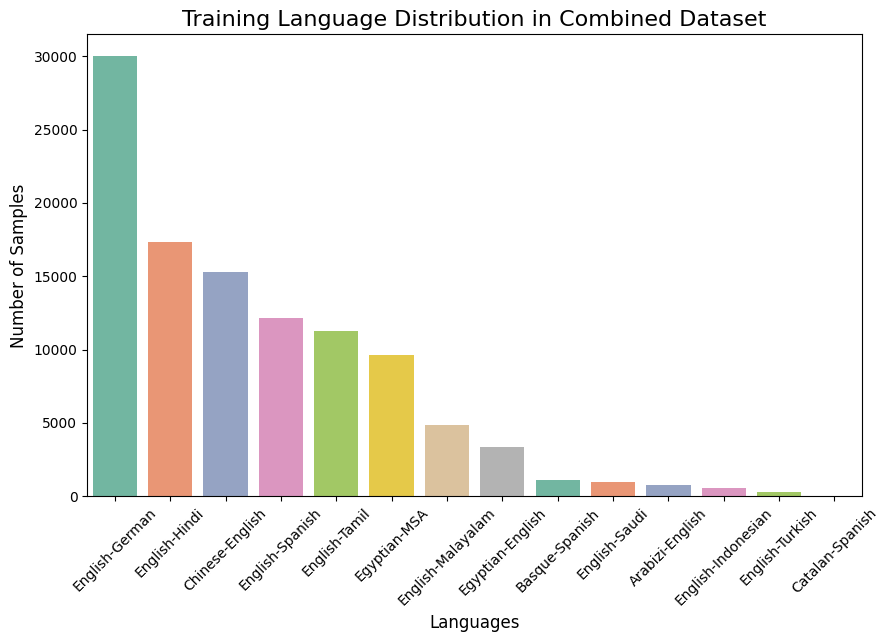

In [130]:
plt.figure(figsize=(10, 6))
sns.barplot(x=train_language_counts_filtered.index, y=train_language_counts_filtered.values, palette='Set2')

plt.title('Training Language Distribution in Combined Dataset', fontsize=16)
plt.xlabel('Languages', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3645720/4276663964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_language_counts_filtered.index, y=test_language_counts_filtered.values, palette='Set2')


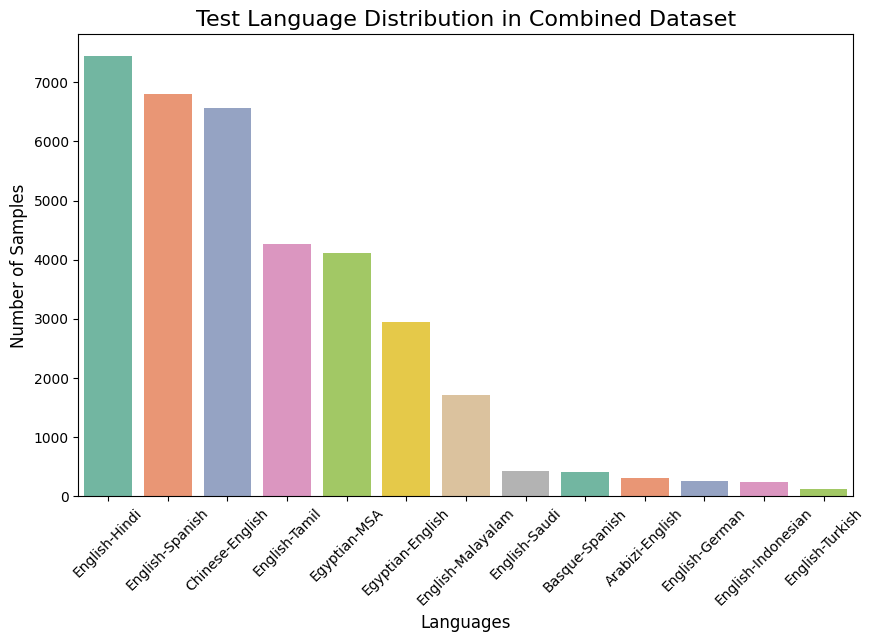

In [131]:
plt.figure(figsize=(10, 6))
sns.barplot(x=test_language_counts_filtered.index, y=test_language_counts_filtered.values, palette='Set2')

plt.title('Test Language Distribution in Combined Dataset', fontsize=16)
plt.xlabel('Languages', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

plt.xticks(rotation=45)
plt.show()

In [132]:
train_combined_cs_df.to_csv('train_combined_cs_dataset.csv', index=False)
test_combined_cs_df.to_csv('test_combined_cs_dataset.csv', index=False)

In [133]:
train_combined_cs_df

,codeswitch_sentence,languages
0,sehr gut von einem EXPERTEN und nicht von SCHW...,English-German
1,旅鸽在 1914 年灭绝，它的数量曾经数以十亿计，如此庞大的群体是如何在短时间内灭绝的呢？根...,Chinese-English
2,Escucha lo que dijo @jbalvin de #bobo Y Viste ...,English-Spanish
3,Ufffffff ichayaaa pwolich ur die hard fan 4 ever,English-Malayalam
4,"Halt die Fresse, ihr Linksfadchisten seid für ...",English-German
...,...,...
107598,memorizar : Know something by heart . I know t...,English-Spanish
107599,Epoche FRAGEN JETZT aber voll das Thema A Tech...,English-German
107600,هيحصل,Egyptian-MSA
107601,طيب [HES] انت جربت قبل كده في evaluation لو في...,Egyptian-English


In [134]:
language_distribution = train_combined_cs_df['languages'].value_counts().reset_index()
language_distribution.columns = ['Language Pair', 'Count']

print(language_distribution)

         Language Pair  Count
0       English-German  30000
1        English-Hindi  17361
2      Chinese-English  15313
3      English-Spanish  12136
4        English-Tamil  11237
5         Egyptian-MSA   9606
6    English-Malayalam   4839
7     Egyptian-English   3344
8       Basque-Spanish   1087
9        English-Saudi    994
10     Arabizi-English    738
11  English-Indonesian    577
12     English-Turkish    273
13     Catalan-Spanish     35


In [135]:
language_distribution = train_combined_cs_df['languages'].value_counts(normalize=False).reset_index()
language_distribution.columns = ['Language Pair', 'Count']
language_distribution['Percentage'] = (language_distribution['Count'] / len(train_combined_cs_df)) * 100
print(language_distribution)


         Language Pair  Count  Percentage
0       English-German  30000   27.896597
1        English-Hindi  17361   16.143760
2      Chinese-English  15313   14.239353
3      English-Spanish  12136   11.285103
4        English-Tamil  11237   10.449135
5         Egyptian-MSA   9606    8.932490
6    English-Malayalam   4839    4.499721
7     Egyptian-English   3344    3.109541
8       Basque-Spanish   1087    1.010787
9        English-Saudi    994    0.924307
10     Arabizi-English    738    0.686256
11  English-Indonesian    577    0.536545
12     English-Turkish    273    0.253859
13     Catalan-Spanish     35    0.032546


In [136]:
language_distribution = test_combined_cs_df['languages'].value_counts(normalize=False).reset_index()
language_distribution.columns = ['Language Pair', 'Count']
language_distribution['Percentage'] = (language_distribution['Count'] / len(test_combined_cs_df)) * 100
print(language_distribution)


         Language Pair  Count  Percentage
0        English-Hindi   7441   20.893469
1      English-Spanish   6797   19.085191
2      Chinese-English   6563   18.428146
3        English-Tamil   4270   11.989667
4         Egyptian-MSA   4118   11.562869
5     Egyptian-English   2940    8.255181
6    English-Malayalam   1710    4.801483
7        English-Saudi    427    1.198967
8       Basque-Spanish    412    1.156848
9      Arabizi-English    317    0.890099
10      English-German    253    0.710395
11  English-Indonesian    248    0.696355
12     English-Turkish    118    0.331330


In [ ]:
combined_df = pd.concat([train_combined_cs_df, test_combined_cs_df], ignore_index=True)

dataset_counts = combined_df.groupby('dataset_source').size().reset_index(name='count')

print(dataset_counts)

                         dataset_source  count
0                                ASCEND   3320
1                              ArzEn-ST   6284
2                                 BaSCo   1372
3                              CroCoSum  18556
4                     Dravidian-CodeMix  20886
5                                   EDC  13724
6                                 HinGE   4799
7                             Saudilang   1421
8                               SemEval  38813
9                        TongueSwitcher  30253
10                             Tweetlid    348
11        barik-etal-2019-normalization    825
12                    sabty2021language   1055
13  yirmibesoglu-eryigit-2018-detecting    391
